# Imports

 

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cdist

# Data Import

In [8]:
#import to dataframe
file_path = "Longotor1delta.xls"
df = pd.read_excel(file_path)

#preview of dataset
print("First 5 rows:")
print(df.head())
print("\nColumns:")
print(df.columns.tolist())
print("\nShape:")
print(df.shape)

First 5 rows:
  Public ID        Gene                                   Gene description  \
0   YAL001C        TFC3  Largest of six subunits of the RNA polymerase ...   
1   YAL002W        VPS8  Membrane-associated hydrophilic protein that i...   
2   YAL003W        EFB1  Translation elongation factor 1 beta, stimulat...   
3   YAL005C  SSA2  SSA1  ATP binding protein involved in protein foldin...   
4   YAL007C        ERP2  Protein that forms a heterotrimeric complex wi...   

    sch9/wt   ras2/wt   tor1/wt  Unnamed: 6  Unnamed: 7  Unnamed: 8  
0 -0.330611 -0.591746 -0.405035         NaN         NaN         NaN  
1  0.043376 -0.113738  0.006602         NaN         NaN         NaN  
2  0.457423  0.305146  0.425690         NaN         NaN         NaN  
3  0.404616  0.526297  0.540533         NaN         NaN         NaN  
4  0.261135  0.609976  0.468309         NaN         NaN         NaN  

Columns:
['Public ID', 'Gene', 'Gene description', 'sch9/wt', 'ras2/wt', 'tor1/wt', 'Unnamed: 6'

# Data Cleaning
We identified the columns used for identification and the three columns containing numeric data about the genes. We removed all other columns, 'Unnamed: 6', 'Unnamed: 7', and 'Unnamed: 8', then dropped all N/A values. We normalized the numerical data with StandardScalar to ensure they are comparible for accurate clustering.


In [10]:
#keep needed columns
id_cols = ["Public ID", "Gene", "Gene description"]
feature_cols = ["sch9/wt", "ras2/wt", "tor1/wt"]
df = df[id_cols + feature_cols].copy()
#drop missing values
df = df.dropna(subset=feature_cols)
print("\nCleaned dataset shape:")
print(df.shape)


Cleaned dataset shape:
(5667, 6)


In [17]:
#isolate columns with numerical data
X = df[feature_cols].values
#scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFirst 5 rows of normalized data:")
print(X_scaled[:5])



First 5 rows of normalized data:
[[-0.67404716 -0.81083905 -0.93142952]
 [ 0.09967535 -0.0915476  -0.02340987]
 [ 0.95627538  0.53877375  0.90104548]
 [ 0.84702556  0.87155555  1.15437581]
 [ 0.55018509  0.99747205  0.99505882]]


In [28]:
def k_means(X, n_clusters=3, random_state=13, n_init=10):
    """runs and reports results of k means clustering on input dataset"""

    model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)
    labels = model.fit_predict(X)

    result = {
        "model": model,
        "labels": labels,
        "silhouette_score": silhouette_score(X, labels) if n_clusters > 1 else None,
        "cluster_centers": model.cluster_centers_
    }
    return result

In [ ]:
def hierarchical(X, n_clusters=3, linkage_method="ward", distance_metric="euclidean"):
    """runs and reports results of agglomerative hierarchical clustering on input dataset
        Note: ward linkage only works with euclidean distance"""
    
    if linkage_method == "ward" and distance_metric != "euclidean":
        raise ValueError("Ward linkage only supports euclidean distance.")

    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric=distance_metric,
        linkage=linkage_method
    )
    labels = model.fit_predict(X)

    result = {
        "model": model,
        "labels": labels,
        "silhouette_score": silhouette_score(X, labels) if n_clusters > 1 else None
    }
    return result

In [33]:
def attach_cluster_labels(df, labels, cluster_col_name="Cluster"):
    """
    Attach cluster labels back to the original dataframe.
    """
    df_copy = df.copy()
    df_copy[cluster_col_name] = labels
    return df_copy


def print_cluster_members(df, id_cols, cluster_col_name="Cluster", max_rows=10):
    """
    Print sample members from each cluster.
    """
    for cluster_id in sorted(df[cluster_col_name].unique()):
        print(f"\nCluster {cluster_id}")
        print(df[df[cluster_col_name] == cluster_id][id_cols].head(max_rows))

### Visualization Helper Functions



In [21]:
def plot_clusters_2d(X, labels, feature_cols, title):
    """
    Plot first two features for quick cluster visualization.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.xlabel(feature_cols[0])
    plt.ylabel(feature_cols[1])
    plt.title(title)
    plt.grid(True)
    plt.show()


def plot_dendrogram(X, method="ward"):
    """
    Plot dendrogram for hierarchical clustering.
    """
    linked = linkage(X, method=method)
    plt.figure(figsize=(12, 6))
    dendrogram(linked, no_labels=True)
    plt.title(f"Dendrogram ({method} linkage)")
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.show()


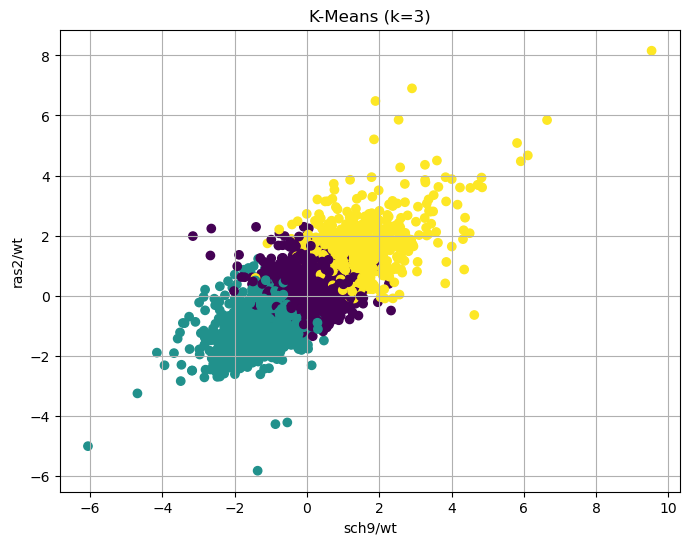

In [42]:
kmeans_result = k_means(X_scaled)
plot_clusters_2d(X_scaled, kmeans_result["labels"], feature_cols, "K-Means (k=3)")

In [35]:
df_kmeans = attach_cluster_labels(df, kmeans_result["labels"], "KMeans_Cluster")
print_cluster_members(df_kmeans, id_cols, "KMeans_Cluster")


Cluster 0
    Public ID   Gene                                   Gene description
1     YAL002W   VPS8  Membrane-associated hydrophilic protein that i...
6     YAL009W   SPO7  Integral nuclearER membrane protein of unknown...
7     YAL010C  MDM10  Subunit of the mitochondrial sorting and assem...
10    YAL013W   DEP1  Transcriptional modulator involved in the regu...
12    YAL015C   NTG1  DNA N-glycosylase and apurinicapyrimidinic (AP...
13  YAL016C-B    ---           Identified by fungal homology and RT-PCR
14    YAL016W   TPD3  Regulatory subunit A of the heterotrimeric pro...
16    YAL018C    ---                               Hypothetical protein
18    YAL020C   ATS1  Protein with a potential role in regulatory in...
19    YAL021C   CCR4  Component of the CCR4-NOT transcriptional comp...

Cluster 1
   Public ID   Gene                                   Gene description
0    YAL001C   TFC3  Largest of six subunits of the RNA polymerase ...
8    YAL011W   SWC3  Protein of unknown func